In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
matplotlib.rcParams['pdf.fonttype'] = 42

In [2]:
sc.set_figure_params(dpi=100, frameon=False, figsize=(6, 5))

In [3]:
adata = sc.read_h5ad('/nfs/team292/vl6/Endometriosis/MenopauseEutopic/INCLIVA_preprocessed.h5ad')
adata

AnnData object with n_obs × n_vars = 40703 × 26035
    obs: 'n_genes', 'sample', 'library', 'donor', 'percent_mito', 'n_counts', 'percent_ribo', 'doublet_scores', 'predicted_doublets', 'batch', 'leiden', 'celltype', 'leiden_R', 'celltype_epi'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'genome-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'genome-10', 'n_cells-10', 'gene_ids-11', 'feature_types-11', 'genome-11', 'n_cells-11', 'gene_ids-12', 'feature_types-12', 'genome-12', 'n_cells-12', 'gene_ids-13', 'feature_types-13', 'genome-13', 'n_cells-13', 'gene_ids-14', 'feature_types-14', 'genome-14', 'n_cells-14', 'gene_ids-15', 'feature_types-15', 'genome-15', 'n_cells-15', 'gene_ids-16', 'feature_types-16', 'genome-16', 'n_cells-16', 'gene_ids-17', 'feature_types-17', 'genome-17', 'n_cells-17', 'gene_ids-18', 'feature_types-18', 'genome-18', 'n_cells-18', 'gene_ids-19', 'feature_types-19', 'genome-19', 'n_cells-19', 'gene_ids-2'

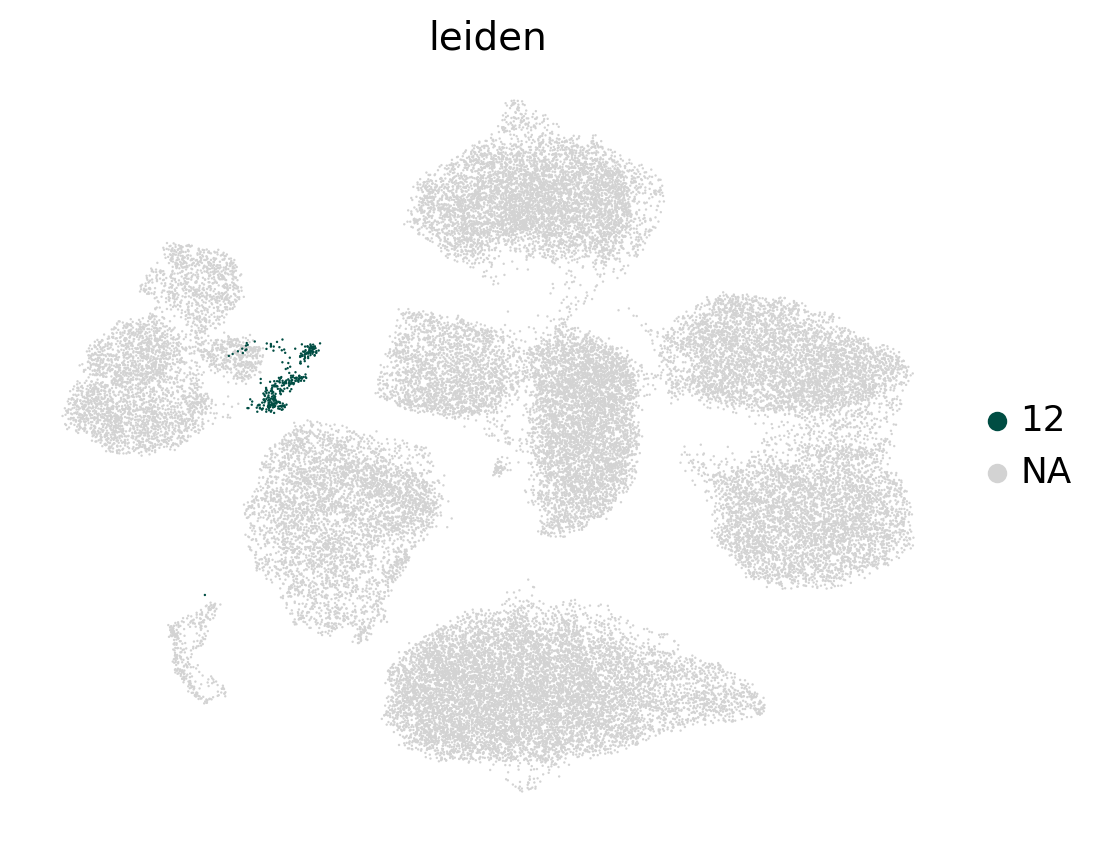

In [4]:
sc.pl.umap(
    adata, 
    color = 'leiden', 
    groups = '12',
    frameon = False
)

In [5]:
adata.obs['leiden_original'] = adata.obs['leiden'].copy()

In [6]:
adata.obs['leiden'] = adata.obs['leiden_original'] 

In [7]:
# ── Template — duplicate this cell for each cluster to re-split ───────────────
# Uncomment and adjust cluster ID and resolution as needed

sc.tl.leiden(adata, resolution=0.1, restrict_to=('leiden', ['12']), neighbors_key = 'neighbors_harmony',
             flavor='igraph', n_iterations=2, directed=False)

adata.obs['leiden_R'] = adata.obs['leiden_R'].cat.rename_categories(
    [str(i) for i in range(len(adata.obs['leiden_R'].cat.categories))]
)

adata.obs['leiden'] = adata.obs['leiden_R']


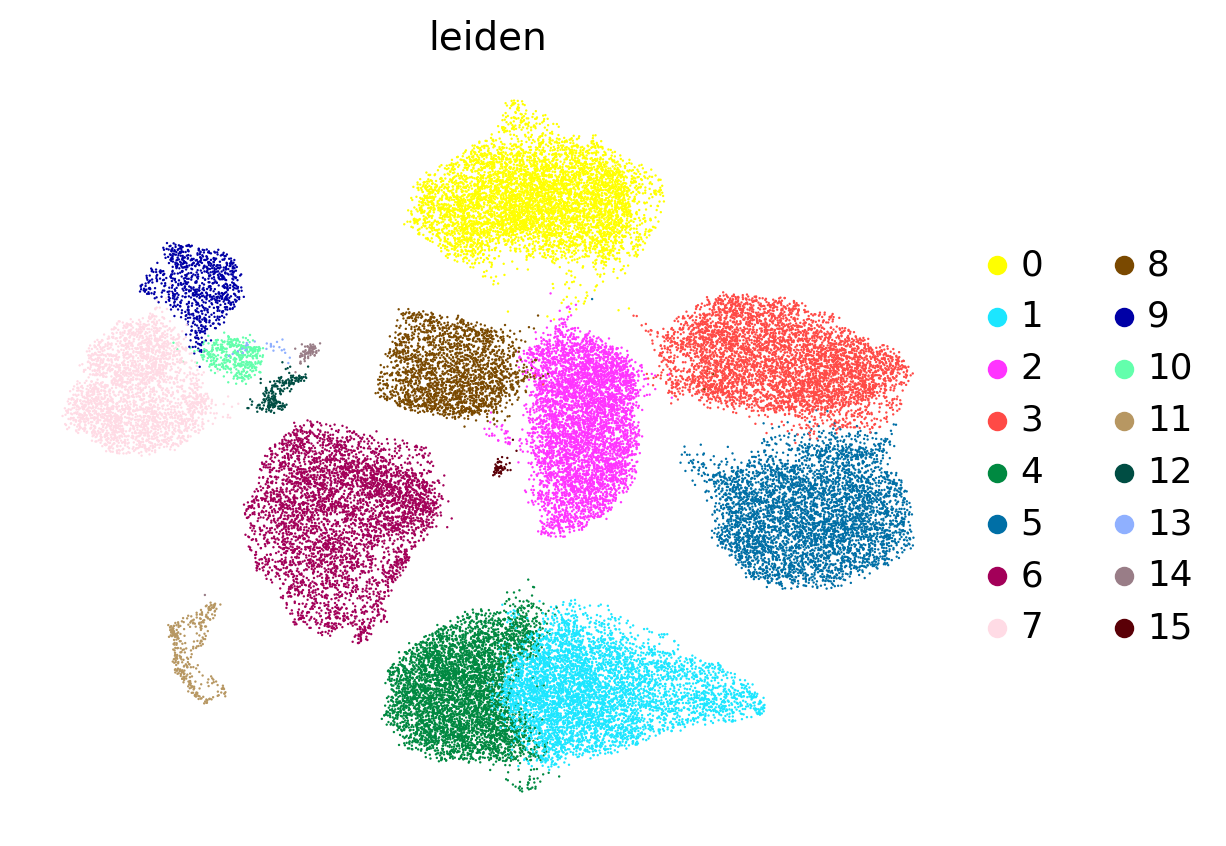

In [8]:
sc.pl.umap(
    adata, 
    color = 'leiden', 
    # legend_loc = 'on data',
    frameon = False
)

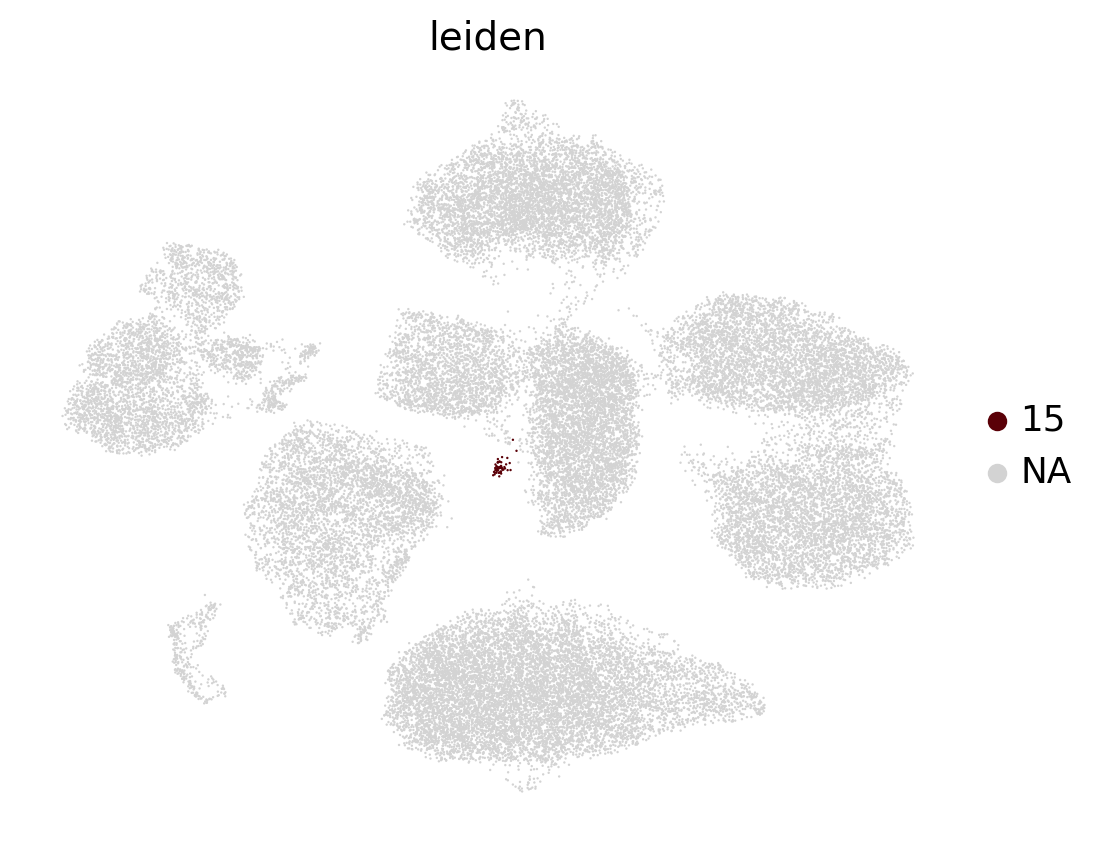

In [9]:
sc.pl.umap(
    adata, 
    color = 'leiden',
    groups = ['15'],
    # legend_loc = 'on data',
    frameon = False
)

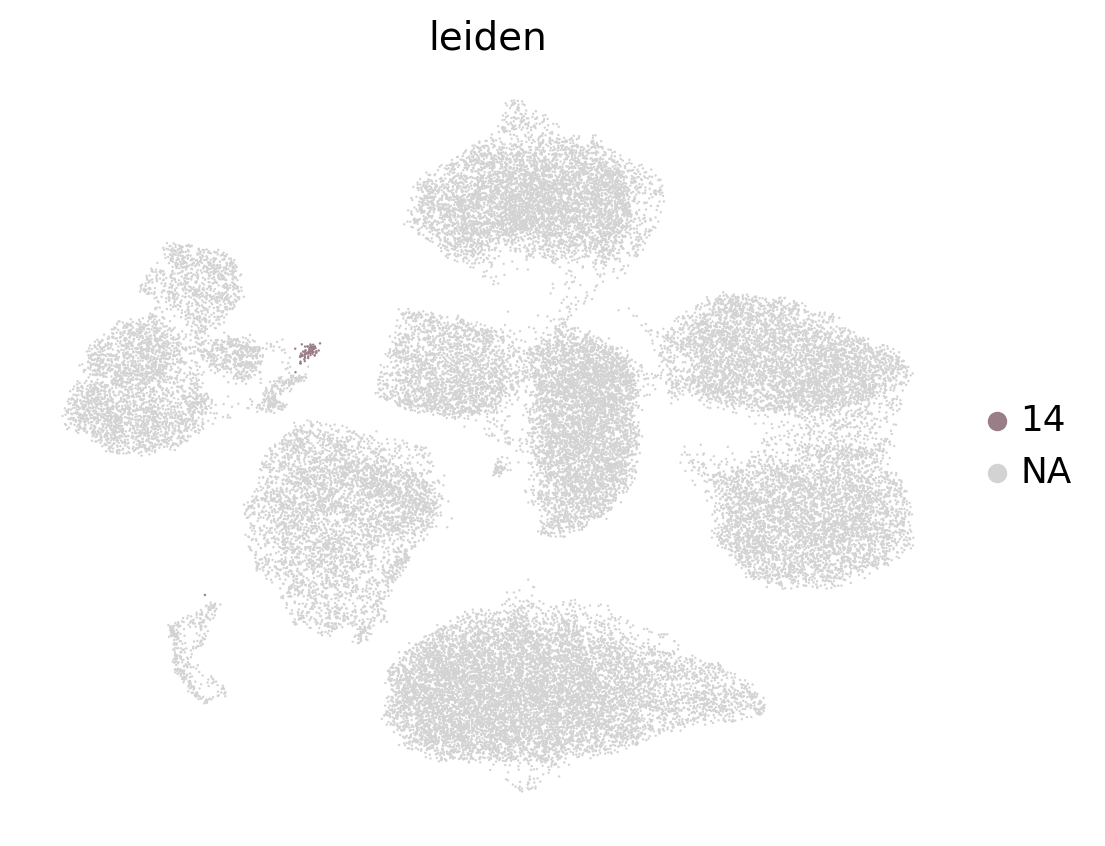

In [10]:
sc.pl.umap(
    adata, 
    color = 'leiden',
    groups = ['14'],
    # legend_loc = 'on data',
    frameon = False
)

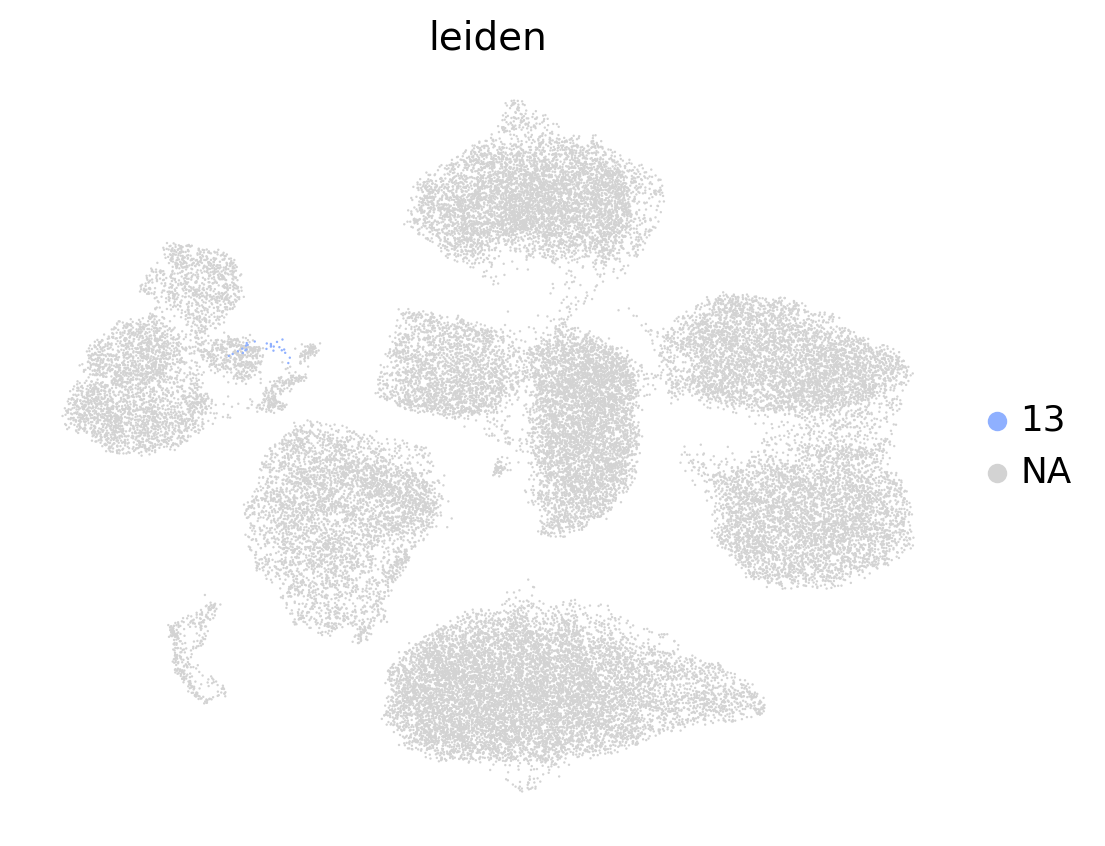

In [11]:
sc.pl.umap(
    adata, 
    color = 'leiden',
    groups = ['13'],
    # legend_loc = 'on data',
    frameon = False
)

In [12]:
adata.obs['leiden'].value_counts()

leiden
0     5720
1     5183
2     4983
3     4694
4     4591
5     4447
6     4254
7     2694
8     2193
9      842
10     410
11     330
12     213
14      72
15      51
13      26
Name: count, dtype: int64

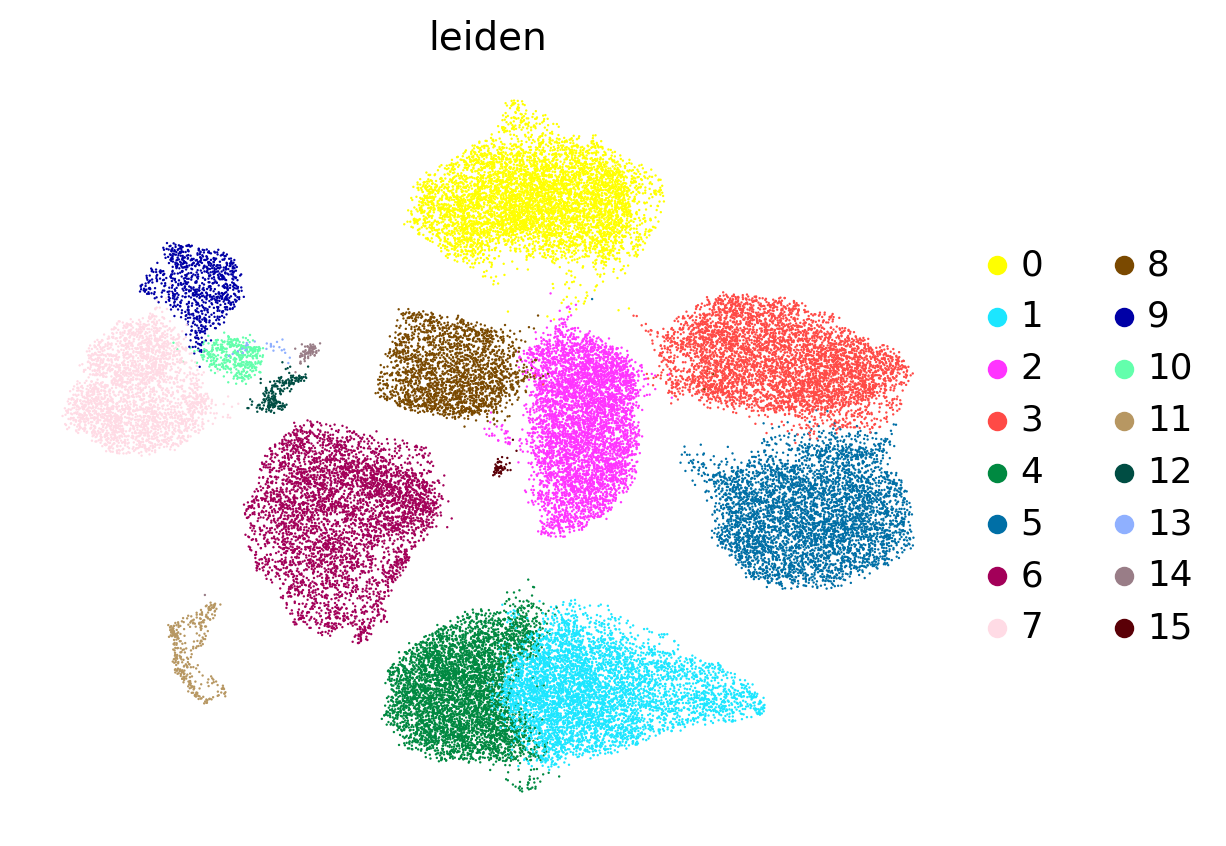

In [13]:
sc.pl.umap(
    adata, 
    color = 'leiden', 
    # legend_loc = 'on data',
    frameon = False
)

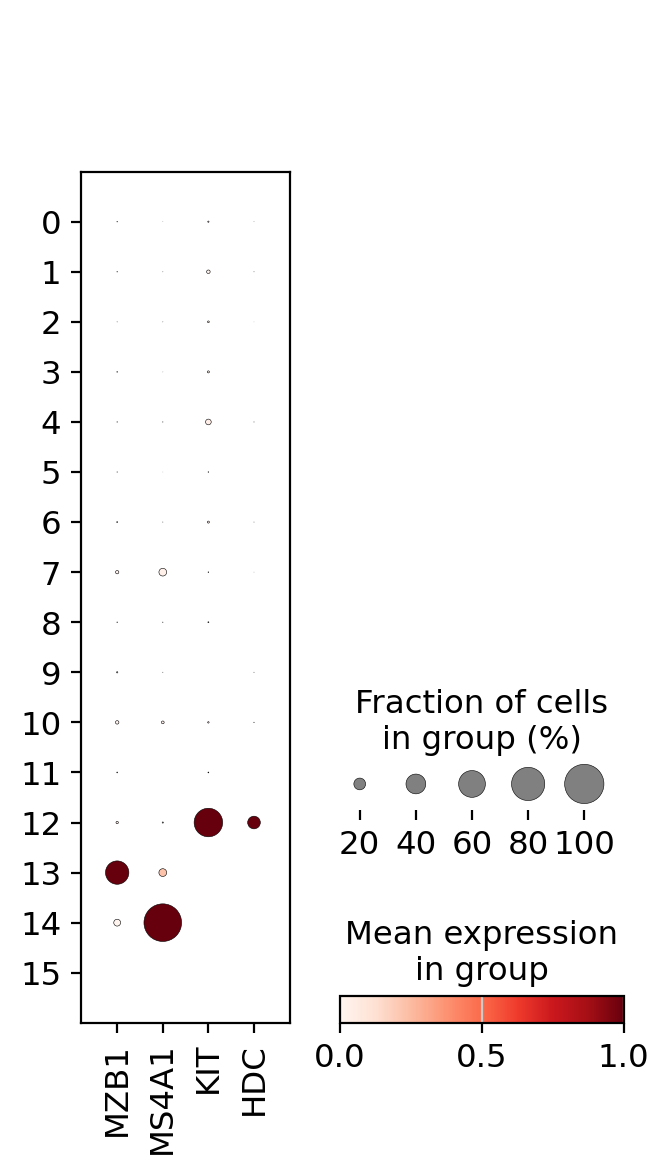

In [14]:
sc.pl.dotplot(
    adata, 
    ['MZB1', 'MS4A1', 'KIT', 'HDC'],
    groupby = 'leiden', 
    standard_scale = 'var'
)

In [15]:
adata.obs['celltype_epi2'] = adata.obs['celltype_epi'].copy()

adata.obs['celltype_epi2'] = np.where(
    adata.obs['leiden'] == '12',
    'mast cell', 
    adata.obs['celltype_epi2']
)

adata.obs['celltype_epi2'] = np.where(
    adata.obs['leiden'] == '13',
    'B/plasma cell', # plasma cell
    adata.obs['celltype_epi2']
)

adata.obs['celltype_epi2'] = np.where(
    adata.obs['leiden'] == '14',
    'B/plasma cell', # B cells
    adata.obs['celltype_epi2']
)

In [16]:
adata.obs['celltype_epi2'] = adata.obs['celltype_epi2'].replace(
    {'lymphoid_T' : 'T cell',
     'lymphoid_NK' : 'NK cell'
    }
)

In [17]:
adata.obs['celltype_epi2'] = pd.Categorical(adata.obs['celltype_epi2'],
                                            categories = ['epi_basalis_glands', 'epi_functionalis_glands', 'epi_lumen',
 'epi_mucinous',  'mesenchyme_RORB', 'mesenchyme_C7',
 'SMC',  'PV_STEAP4','PV_RERGL',
 'endothelial',
 'T cell', 'NK cell', 
                                                          # 'B cell', 'plasma cell', 
                                                          'B/plasma cell',
                                                          'mast cell', 'myeloid', 'neural'],
                                            ordered = True
                                           )

In [18]:
adata.obs['celltype_epi2'].cat.categories

Index(['epi_basalis_glands', 'epi_functionalis_glands', 'epi_lumen',
       'epi_mucinous', 'mesenchyme_RORB', 'mesenchyme_C7', 'SMC', 'PV_STEAP4',
       'PV_RERGL', 'endothelial', 'T cell', 'NK cell', 'B/plasma cell',
       'mast cell', 'myeloid', 'neural'],
      dtype='object')

In [19]:
adata.obs['celltype_epi2'].value_counts()

celltype_epi2
endothelial                9774
SMC                        5720
mesenchyme_C7              4983
PV_STEAP4                  4694
PV_RERGL                   4447
T cell                     3104
epi_functionalis_glands    2566
mesenchyme_RORB            2193
epi_basalis_glands         1118
NK cell                     842
epi_lumen                   421
myeloid                     330
mast cell                   213
epi_mucinous                149
B/plasma cell                98
neural                       51
Name: count, dtype: int64

In [20]:
palette = [
    # Epithelium
    "darkgreen",    # epi_basalis_glands
    "forestgreen",  # epi_functionalis_glands
    "olive",        # epi_lumen
    "yellowgreen",  # epi_mucinous

    # Mesenchyme
    "#86A8C9",  # mesenchyme_RORB
    "#D7E6F5",  # mesenchyme_C7

    # Mural cells
    "#B5CCE2",  # SMC
    "#6E97BE",  # PV_STEAP4
    "#3E5F7D",  # PV_RERGL

    # Endothelium
    "#C97B63",  # endothelial

    # Lymphoid
    "#DDD6E8",  # T cell
    "#B7A7CC",  # NK cell
    "#8A759F",  # B cell
    # "#6F5C85",  # plasma cell
    "#4E3F63",  # mast cell

    # Myeloid
    "#5B4C6A",  # myeloid

    # Neural
    "#9A8F6A",  # neural
]

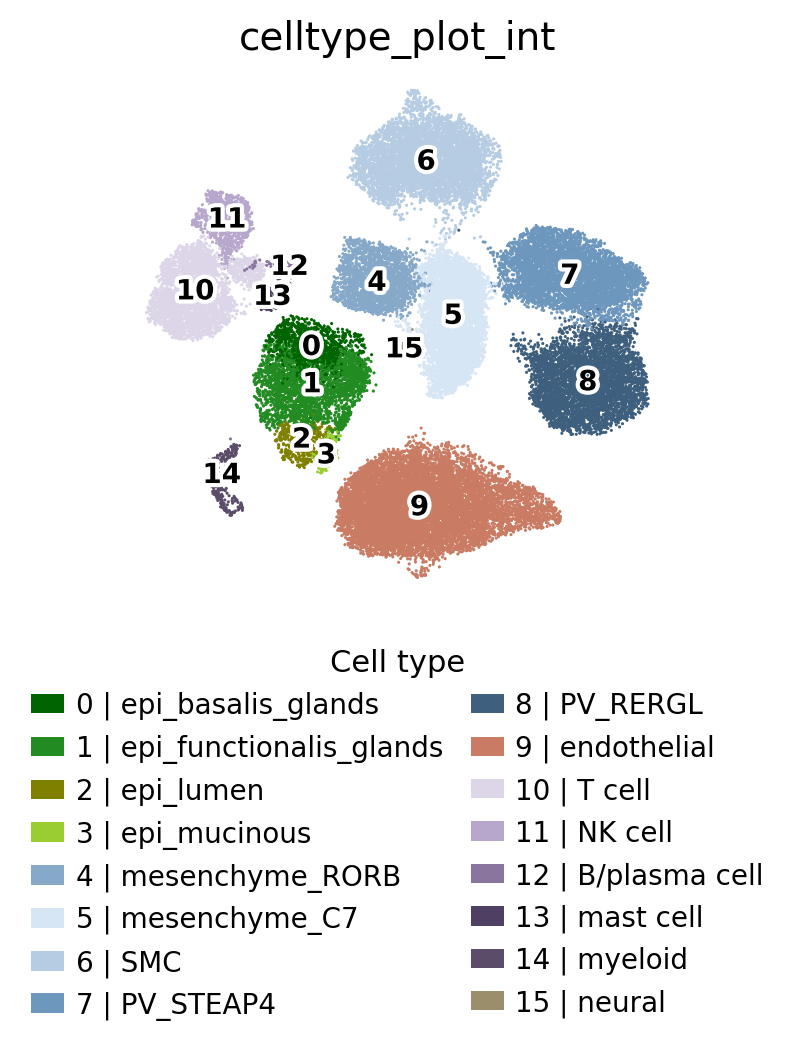

In [21]:
# -----------------------------
# Settings
# -----------------------------
celltype_col = "celltype_epi2"
int_col = "celltype_plot_int"
category_order = adata.obs['celltype_epi'].cat.categories

# # -----------------------------
# # Set categorical order
# # -----------------------------
# adata.obs[celltype_col] = pd.Categorical(
#     adata.obs[celltype_col],
#     categories=category_order,
#     ordered=True
# )

# -----------------------------
# Create integer categories
# -----------------------------
cats = list(adata.obs[celltype_col].cat.categories)

cat_to_int = {cat: i for i, cat in enumerate(cats)}
int_to_cat = {i: cat for cat, i in cat_to_int.items()}

adata.obs[int_col] = (
    adata.obs[celltype_col]
    .map(cat_to_int)
    .astype("category")
)

# Important: colors must match integer category order
adata.uns[f"{int_col}_colors"] = palette

# -----------------------------
# Match UMAP aspect ratio
# -----------------------------
xy = adata.obsm["X_umap"]
umap_ratio = np.ptp(xy[:, 0]) / np.ptp(xy[:, 1])

fig_h = 4
fig_w = fig_h * umap_ratio

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# -----------------------------
# Plot UMAP
# -----------------------------
sc.pl.umap(
    adata,
    color=int_col,
    legend_loc="on data",
    legend_fontsize=10,
    legend_fontoutline=3,
    size=5,
    frameon=False,
    ax=ax,
    show=False,
    
)

# -----------------------------
# Rasterize ONLY the points
# -----------------------------
for coll in ax.collections:
    coll.set_rasterized(True)

ax.set_aspect("equal", adjustable="box")

# -----------------------------
# External legend
# -----------------------------
colors = adata.uns[f"{int_col}_colors"]

handles = [
    Patch(
        facecolor=colors[i],
        edgecolor="none",
        label=f"{i} | {int_to_cat[i]}"
    )
    for i in range(len(cats))
]

ax.legend(
    handles=handles,
    title="Cell type",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=2,
    fontsize=10,
    title_fontsize=11,
    frameon=False,
    handlelength=1.2,
    columnspacing=1.0,
    handletextpad=0.4
)

plt.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.95,
    bottom=0.28
)

plt.savefig(
    "incliva.pdf",
    bbox_inches="tight",
    dpi = 600
)

plt.show()

In [16]:
donor_palette = [
    "#B07AA1",  # mauve
    "#D37295",  # rose
    "#F28E2B",  # orange
    "#C49A44",  # mustard
    "#7AA974",  # sage
    "#4E9F8A",  # sea green
    "#59A5D8",  # blue
    "#4E79A7",  # navy
    "#9C755F",  # brown
    "#BAB0AC",  # warm grey
    "#E15759",  # coral
]

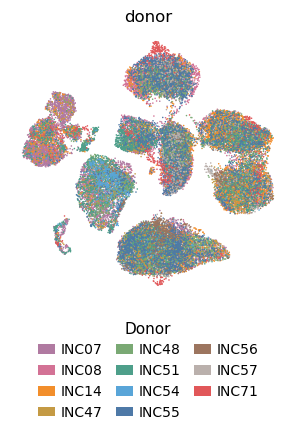

In [20]:
# -----------------------------
# Settings
# -----------------------------
celltype_col = "donor"

# Important: colors must match integer category order
adata.uns[f"{celltype_col}_colors"] = donor_palette

# -----------------------------
# Match UMAP aspect ratio
# -----------------------------
xy = adata.obsm["X_umap"]
umap_ratio = np.ptp(xy[:, 0]) / np.ptp(xy[:, 1])

fig_h = 4
fig_w = fig_h * umap_ratio

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# -----------------------------
# Plot UMAP
# -----------------------------
sc.pl.umap(
    adata,
    color='donor',
    size=5,
    frameon=False,
    ax=ax,
    show=False,
    
)

# -----------------------------
# Rasterize ONLY the points
# -----------------------------
for coll in ax.collections:
    coll.set_rasterized(True)

ax.set_aspect("equal", adjustable="box")

# -----------------------------
# External legend
# -----------------------------
colors = adata.uns[f"{celltype_col}_colors"]

cats = adata.obs[celltype_col].cat.categories

handles = [
    Patch(
        facecolor=colors[i],
        edgecolor="none",
        label=cats[i]
    )
    for i in range(len(cats))
]

ax.legend(
    handles=handles,
    title="Donor",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=10,
    title_fontsize=11,
    frameon=False,
    handlelength=1.2,
    columnspacing=1.0,
    handletextpad=0.4
)

plt.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.95,
    bottom=0.28
)

plt.savefig(
    "incliva_donor.pdf",
    bbox_inches="tight",
    dpi = 600
)

plt.show()